<center> <h1> Zomato Dish Recommender System (Content-Based Recommendation System) </h1> </center>

**This project is made with a sole purpose of building a dish recommender system (based on Content) using cosine similarity.**

In [16]:
#Import required libraries:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


#Ignore all incoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")

In [17]:
#Load the dataset:
df = pd.read_csv("zomato.csv")

## Columns description

- **url:** contains the url of the restaurant in the zomato website
- **address:** contains the address of the restaurant in Bengaluru
- **name:** contains the name of the restaurant
- **online_order:** whether online ordering is available in the restaurant or not
- **book_table:** table book option available or not
- **rate:** contains the overall rating of the restaurant out of 5
- **votes:** contains total number of rating for the restaurant as of the above mentioned date
- **phone:** contains the phone number of the restaurant
- **location:** contains the neighborhood in which the restaurant is located
- **rest_type:** restaurant type
- **dish_liked:** dishes people liked in the restaurant
- **cuisines:** food styles, separated by comma
- **approx_cost(for two people):** contains the approximate cost for meal for two people
- **reviews_list:** list of tuples containing reviews for the restaurant, each tuple
- **menu_item:** contains list of menus available in the restaurant
- **listed_in(type):** type of meal
- **listed_in(city):** contains the neighborhood in which the restaurant is listed

**Data inspection , cleaning and Feature Engineering:**

In [18]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [19]:
df.shape

(51717, 17)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [21]:
df["rate"] = df["rate"].fillna("0/5")
df["dish_liked"] = df["dish_liked"].fillna("0/5")
df.dropna(subset=["phone","location","dish_liked","rest_type","approx_cost(for two people)","cuisines"],inplace=True)
df = df.drop(columns=["listed_in(city)"])



df['rate'] = df['rate'].str.replace('/5', '', regex=False)

def clean_phone(cell):
    if pd.isna(cell):
        return ''
    # Split by line breaks
    numbers = re.split(r'\r\n|\n', cell)
    cleaned_numbers = []
    for num in numbers:
        # Remove spaces, keep only digits
        num = re.sub(r'\D', '', num)
        cleaned_numbers.append(num)
    # Return as list if multiple, or first number only
    return cleaned_numbers[0] if len(cleaned_numbers) > 1 else cleaned_numbers[0]

# Apply cleaning
df['phone'] = df['phone'].apply(clean_phone)






df["rate"] = pd.to_numeric(df["rate"], errors='coerce')
df["phone"] = df["phone"].astype(int)
# Remove commas and convert to int
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",", "").astype(int)
df["approx_cost(for one person)"] = df["approx_cost(for two people)"]/2
df['dish_liked'] = df['dish_liked'].apply(lambda x: x.split(',')[0] if x !='Unknown' else 'Unknown')
df['cuisines'] = df['cuisines'].apply(lambda x: x.split(',')[0] if x !='Unknown' else 'Unknown')
df['rest_type'] = df['rest_type'].apply(lambda x: x.split(',')[0] if x !='Unknown' else 'Unknown')




#Remove invalid values in the 'dish_liked' attribute:
invalid_values = [
    "0/5",
    "Not Available",
    "None",
    "nan",
    ""
]

df = df[~df["dish_liked"].isin(invalid_values)]

**EDA Questions:**

In [22]:
#Places from where we are getting most orders:
df["location"].value_counts().reset_index(name="No. of orders").head(5)

,location,No. of orders
0,Koramangala 5th Block,1784
1,BTM,1460
2,Indiranagar,1350
3,HSR,1162
4,Jayanagar,1047


In [23]:
#Places from where we are getting low orders:
df["location"].value_counts().reset_index(name="No. of orders").sort_values(by="No. of orders",ascending=True).head(5)

,location,No. of orders
87,KR Puram,1
84,West Bangalore,2
85,Yelahanka,2
86,Magadi Road,2
82,Rajarajeshwari Nagar,2


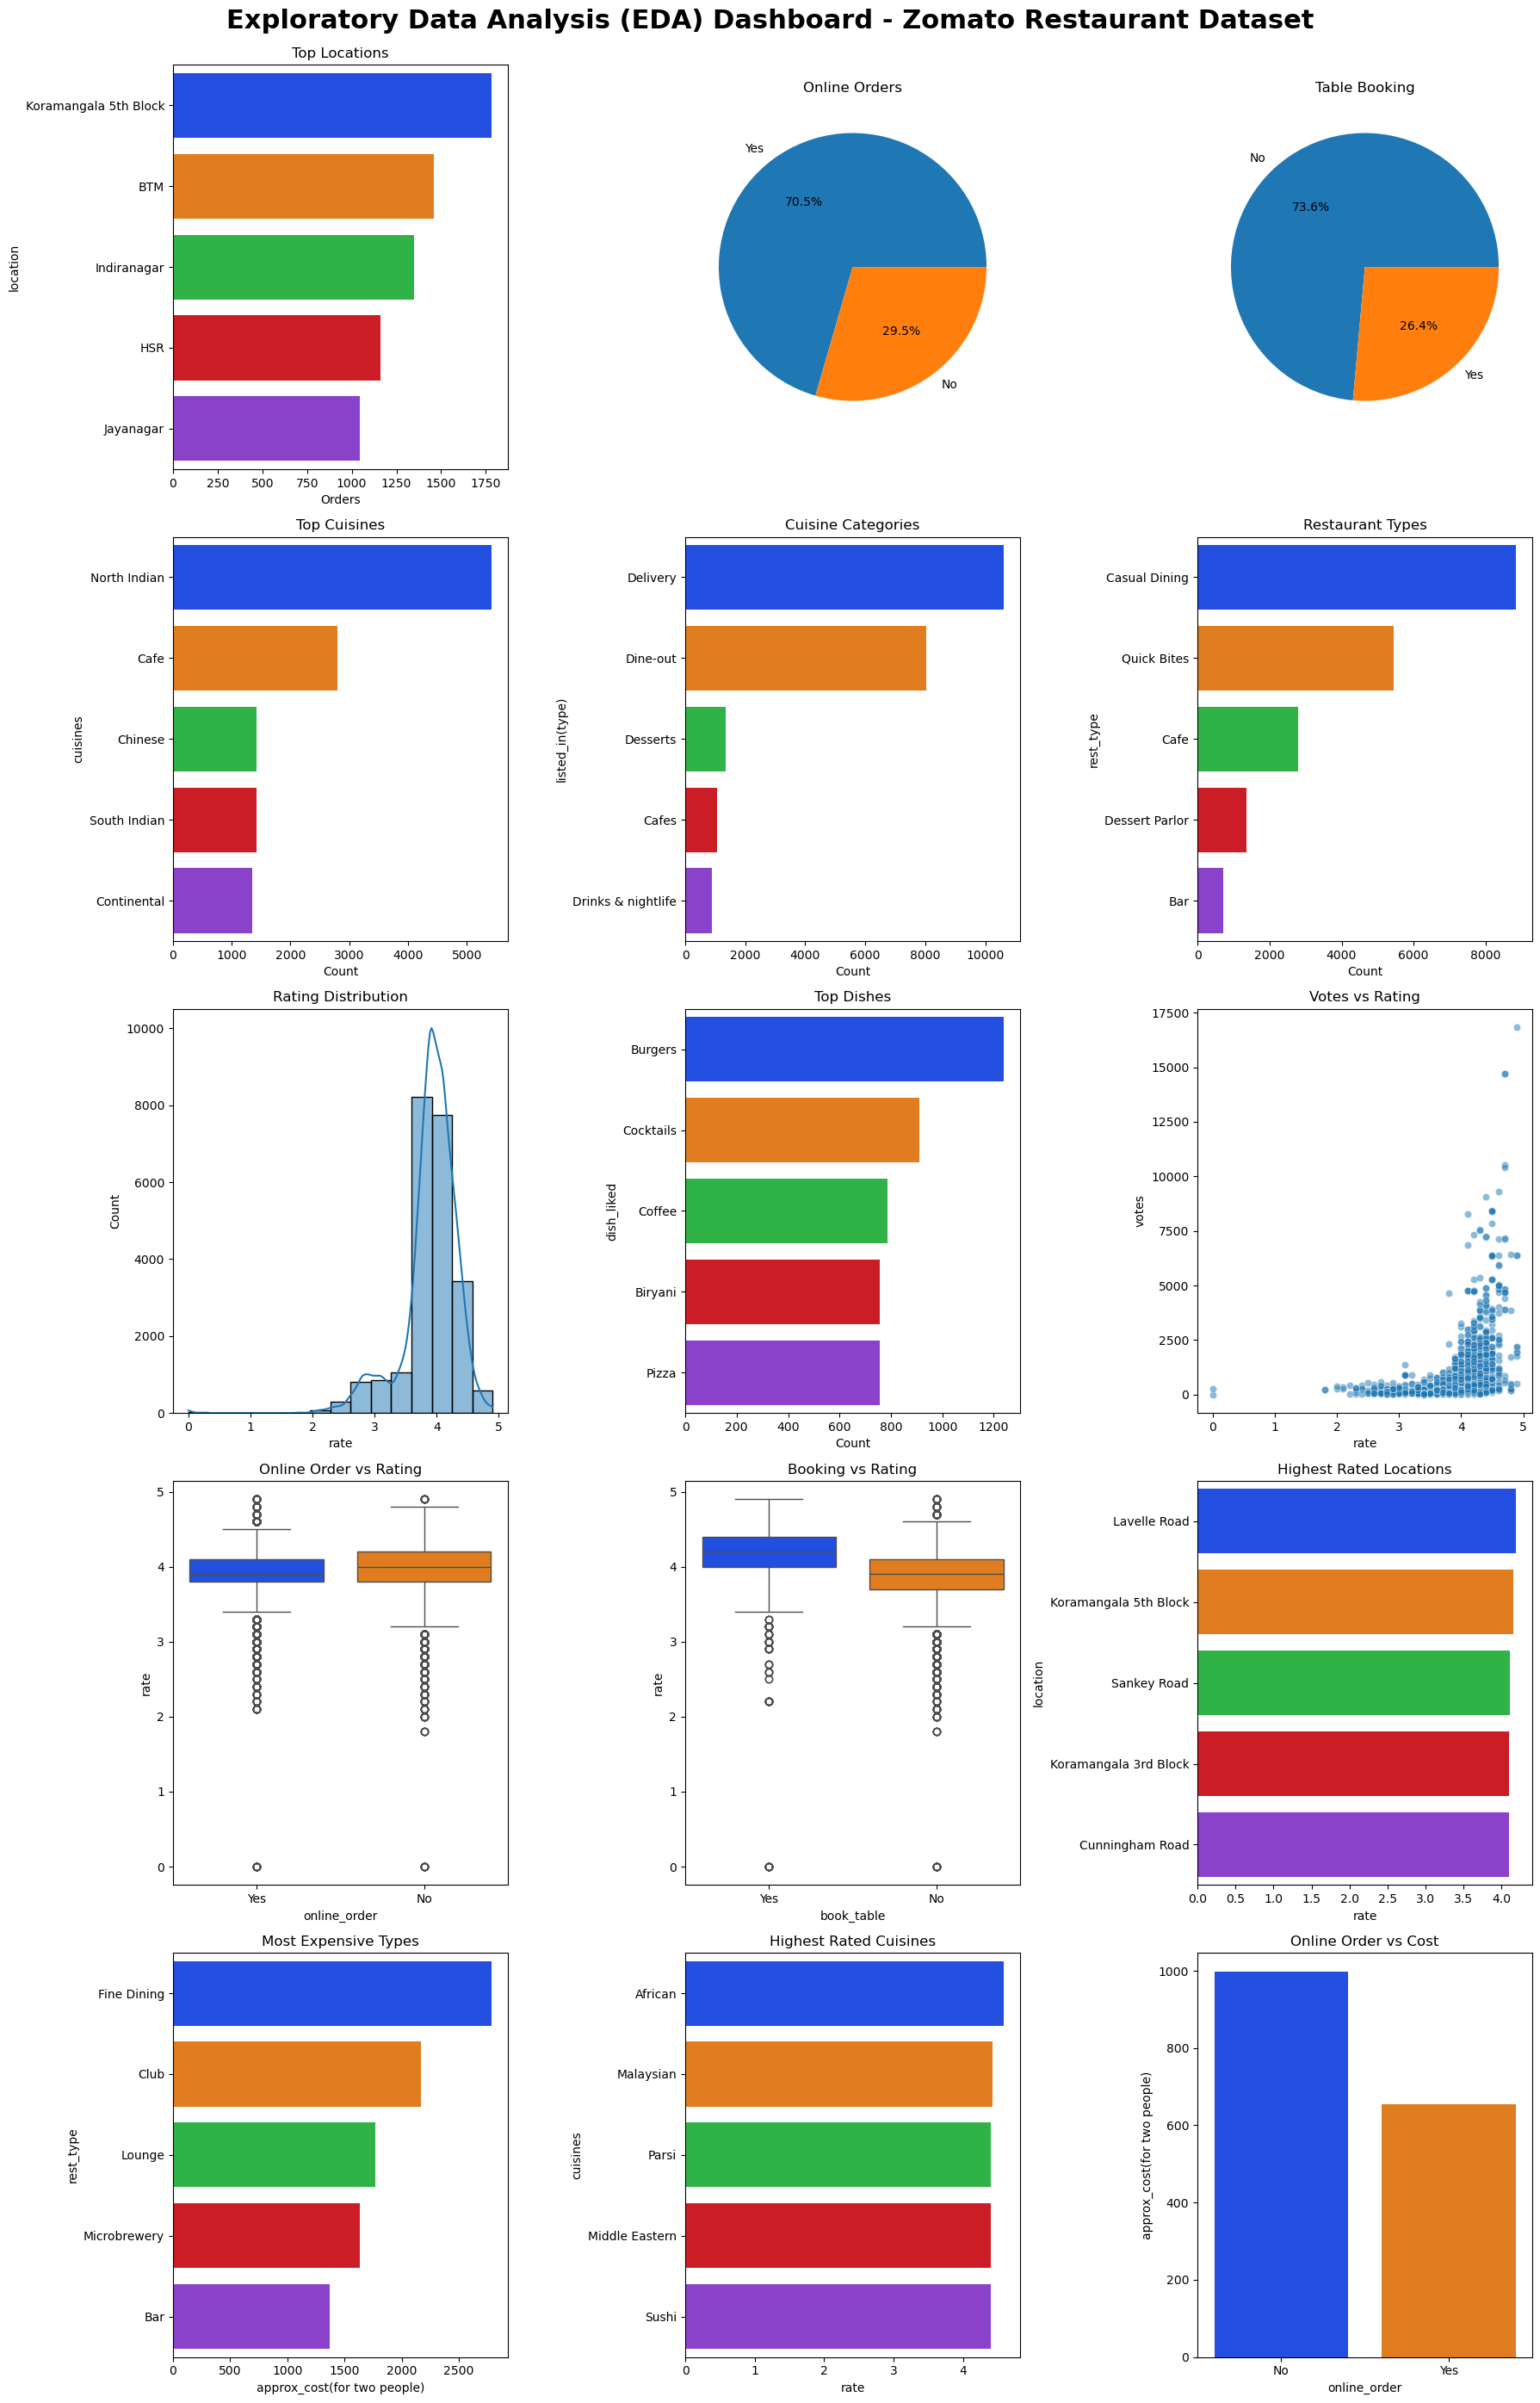

In [24]:
plt.figure(figsize=(18,28))

plt.suptitle(
    "Exploratory Data Analysis (EDA) Dashboard - Zomato Restaurant Dataset",
    fontsize=22,
    fontweight="bold",
    y=0.995
)

plt.subplot(5,3,1)
data = df["location"].value_counts().head(5).reset_index(name="Orders")
sns.barplot(data=data, x="Orders", y="location", palette="bright")
plt.title("Top Locations")

plt.subplot(5,3,2)
counts = df["online_order"].value_counts()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Online Orders")

plt.subplot(5,3,3)
counts = df["book_table"].value_counts()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Table Booking")


plt.subplot(5,3,4)
data = df["cuisines"].value_counts().head(5).reset_index(name="Count")
sns.barplot(data=data, x="Count", y="cuisines", palette="bright")
plt.title("Top Cuisines")

plt.subplot(5,3,5)
data = df["listed_in(type)"].value_counts().head(5).reset_index(name="Count")
sns.barplot(data=data, x="Count", y="listed_in(type)", palette="bright")
plt.title("Cuisine Categories")

plt.subplot(5,3,6)
data = df["rest_type"].value_counts().head(5).reset_index(name="Count")
sns.barplot(data=data, x="Count", y="rest_type", palette="bright")
plt.title("Restaurant Types")

plt.subplot(5,3,7)
sns.histplot(df["rate"], bins=15, kde=True)
plt.title("Rating Distribution")

plt.subplot(5,3,8)
data = df[df["dish_liked"]!="0/5"]["dish_liked"].value_counts().head(5).reset_index(name="Count")
sns.barplot(data=data, x="Count", y="dish_liked", palette="bright")
plt.title("Top Dishes")

plt.subplot(5,3,9)
sns.scatterplot(
    data=df.sample(3000, random_state=42),
    x="rate",
    y="votes",
    alpha=0.5
)
plt.title("Votes vs Rating")

plt.subplot(5,3,10)
sns.boxplot(data=df, x="online_order", y="rate", palette="bright")
plt.title("Online Order vs Rating")

plt.subplot(5,3,11)
sns.boxplot(data=df, x="book_table", y="rate", palette="bright")
plt.title("Booking vs Rating")

plt.subplot(5,3,12)
data = df.groupby("location")["rate"].mean().sort_values(ascending=False).head(5).reset_index()
sns.barplot(data=data, x="rate", y="location", palette="bright")
plt.title("Highest Rated Locations")

plt.subplot(5,3,13)
data = df.groupby("rest_type")["approx_cost(for two people)"].mean().sort_values(ascending=False).head(5).reset_index()
sns.barplot(data=data, x="approx_cost(for two people)", y="rest_type", palette="bright")
plt.title("Most Expensive Types")

plt.subplot(5,3,14)
data = df.groupby("cuisines")["rate"].mean().sort_values(ascending=False).head(5).reset_index()
sns.barplot(data=data, x="rate", y="cuisines", palette="bright")
plt.title("Highest Rated Cuisines")


plt.subplot(5,3,15)
data = df.groupby("online_order")["approx_cost(for two people)"].mean().reset_index()
sns.barplot(
    data=data,
    x="online_order",
    y="approx_cost(for two people)",
    palette="bright"
)
plt.title("Online Order vs Cost")

plt.tight_layout()
plt.show()

**Dish Recommender System:**

In [25]:
new_df = df.copy()

In [26]:
cv = CountVectorizer(max_features=5000,stop_words="english")

new_df["tags"] = (
    new_df["rest_type"].astype(str) + " " +
    new_df["location"].astype(str) + " " +
    new_df["cuisines"].astype(str) + " " +
    new_df["listed_in(type)"].astype(str)
)

new_df["tags"] = new_df["tags"].str.lower()

vectors = cv.fit_transform(new_df["tags"]).toarray()

#Compute cosine similarity:
similarity = cosine_similarity(vectors)



def recommend(dish):
    dish_index = new_df[new_df["dish_liked"] == dish].index[0]
    distances = similarity[dish_index]
    dishes_list = sorted(
        list(enumerate(distances)) , 
        reverse=True , 
        key=lambda x: x[1])[1:11]

    for i in dishes_list:
        dish_recommended = new_df.iloc[i[0]].dish_liked
        if(dish_recommended != dish):
            print(dish_recommended , "\t\t\t Cosine similarity :",round(i[1],2))

In [27]:
recommend("Masala Dosa")

Rooftop Ambience 			 Cosine similarity : 0.83
Coffee 			 Cosine similarity : 0.83
Biryani 			 Cosine similarity : 0.83
Jowar Roti 			 Cosine similarity : 0.83
Roti 			 Cosine similarity : 0.83
Chicken Biryani 			 Cosine similarity : 0.83
Coffee 			 Cosine similarity : 0.83
Chicken Grill 			 Cosine similarity : 0.83


In [28]:
#All dishes in the form of vectors:
cv.fit_transform(new_df["tags"]).toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(23222, 213))

**Export the cosine similarity matrix:**

In [29]:
import pickle
pickle.dump(similarity,open("dishes_similarity.pkl","wb"))

**Export the new dataframe (but in the form of a binary file):**

In [30]:
pickle.dump(new_df,open("dishes.pkl","wb"))

**Project by:** 


**Name:** Om Satyawan Pathak <br>
**Email:** omsatyawanpathakwebdevelopment@gmail.com _(or)_ omsatyawanpathakgit@gmail.com <br>
**LinkedIn Profile:** www.linkedin.com/in/om-satyawan-pathak-029b02368 <br>